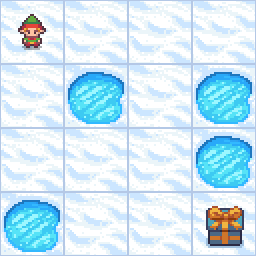

The **Frozen Lake v1** environment, provided by OpenAI Gym, is a popular grid-world environment used in reinforcement learning to test various algorithms. It presents a simple yet challenging scenario, ideal for understanding the basics of learning and decision-making under uncertainty. Check [this link](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) for more details about this environment. This assignment involves understanding the process of training an agent using the SARSA and Q-learning algorithms in the Frozen Lake environment. **What you have to do is correctly filling in the blanks in the code.**

### 0. Import libararies

In [7]:
import gym
import numpy as np
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

### 1. Environment details

In [8]:
# Create env
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False)

#observation, action space
print(f"observation space: {env.observation_space.n}")
print(f"action space: {env.action_space.n}")

observation space: 16
action space: 4


## Description
The game starts with the player at location [0,0] of the frozen lake grid world with the goal located at far extent of the world e.g. [3,3] for the 4x4 environment.

Holes in the ice are distributed in set locations when using a pre-determined map.

The player makes moves until they reach the goal or fall in a hole.

The episode starts with the player in state [0] (location [0, 0]).

The preloaded maps lookes like

"SFFF

FHFH

FFFH

HFFG"


where S stands for start point, H stands for hole, G stands for goal and F stands for the frozen path you can explore.


### 2. SARSA

In [16]:
# Define epilon greedy policy
def epsilon_greedy_policy(Q, state, epsilon=0.1):
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()  # Explore
    else:
        return np.argmax(Q[state])  # Exploit

100%|██████████| 1000/1000 [00:00<00:00, 11924.88it/s]


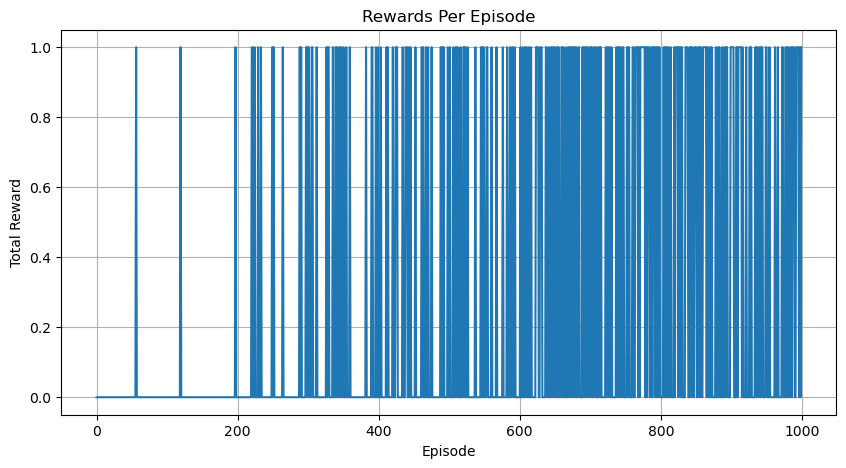

In [69]:
# Create and configure the environment
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False)
num_episodes = 1000 # Do not change
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.999

####### TODO: Initialize Q-table##################################################

x = env.observation_space.n
y = env.action_space.n
Q = np.zeros((x, y))

##################################################################################

rewards = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset()
    action = epsilon_greedy_policy(Q, state, epsilon)
    total_reward = 0

    while True:
        next_state, reward, done, _, _ = env.step(action)
        total_reward += reward
        next_action = epsilon_greedy_policy(Q, next_state, epsilon)
        ####### TODO: update Q function with the estimation of Q(s_{t+1}, a_{t+1})

        Q[state, action] = Q[state, action] + alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])

        ##########################################################################

        state, action = next_state, next_action
        if done:
            rewards.append(total_reward)
            epsilon *= epsilon_decay
            break

# Visualization of rewards
plt.figure(figsize=(10, 5))
plt.plot(rewards)

plt.title('Rewards Per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()



Visualizing the learned policy(as directional arrows, Fill hole with 0):


e.x.

Learned Policy


```
[['↓' '→' '←' '←']
 ['↓' '0' '↓' '0']
 ['→' '→' '↓' '0']
 ['0' '→' '→' '0']]
```



In [70]:
####### TODO: Visualizing the learned policy######################################

policy_map = {0: '←', 1: '↓', 2: '→', 3: '↑'}
policy_grid = np.zeros((4, 4), dtype=str)

for state in range(env.observation_space.n):
    row, col = state // 4, state % 4
    if env.desc[row, col] == b'H':
        policy_grid[row, col] = '0'
    elif env.desc[row, col] == b'G':
        policy_grid[row, col] = '0'
    else:
        best_action = np.argmax(Q[state])
        policy_grid[row, col] = policy_map[best_action]

print("Learned Policy (as directional arrows):")
print(policy_grid)

##################################################################################

Learned Policy (as directional arrows):
[['↓' '←' '←' '←']
 ['↓' '0' '↓' '0']
 ['→' '↓' '↓' '0']
 ['0' '→' '→' '0']]


### 3. Q-Learning

100%|██████████| 1000/1000 [00:00<00:00, 13212.65it/s]


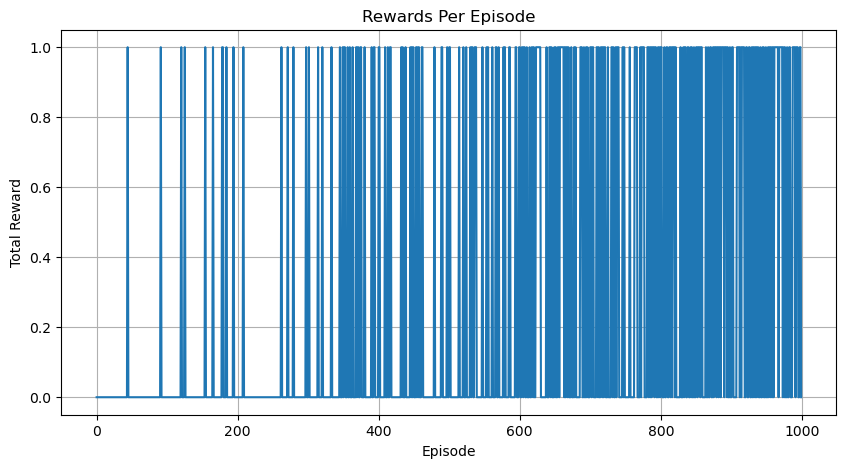

In [75]:
# Create the Frozen Lake environment
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False)
num_episodes = 1000 # Do not change
alpha = 0.01  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.999

####### TODO: Initialize Q-table##################################################

x = env.observation_space.n
y = env.action_space.n
Q = np.zeros((x, y))

##################################################################################
rewards = []  # List to store rewards for each episode

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = epsilon_greedy_policy(Q, state, epsilon)
        next_state, reward, done, _, _ = env.step(action)
        total_reward += reward

        ####### TODO: Q-learning update rule######################################

        # Best action for next state
        best_next_action = np.argmax(Q[next_state])

        # Compute TD target
        td_target = reward + gamma * Q[next_state][best_next_action]

        # Compute TD error
        td_error = td_target - Q[state][action]

        ##########################################################################

        Q[state][action] += alpha * td_error

        state = next_state

    rewards.append(total_reward)
    epsilon *= epsilon_decay # Reduce epsilon

# Plotting the rewards
plt.figure(figsize=(10, 5))
plt.plot(rewards)
plt.title('Rewards Per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()


Visualizing the learned policy(as directional arrows, Fill the hole with 0):

e.x.

Learned Policy


```
[['↓' '→' '←' '←']
 ['↓' '0' '↓' '0']
 ['→' '→' '↓' '0']
 ['0' '→' '→' '0']]
```



In [77]:
####### TODO: Visualizing the learned policy######################################

policy_map = {0: '←', 1: '↓', 2: '→', 3: '↑'}

for state in range(env.observation_space.n):
    row, col = state // 4, state % 4
    if env.desc[row, col] == b'H':
        policy_grid[row, col] = '0'
    elif env.desc[row, col] == b'G':
        policy_grid[row, col] = '0'
    else:
        best_action = np.argmax(Q[state])
        policy_grid[row, col] = policy_map[best_action]

print("Learned Policy (as directional arrows):")
print(policy_grid)

##################################################################################

Learned Policy (as directional arrows):
[['↓' '←' '↓' '←']
 ['↓' '0' '↓' '0']
 ['→' '→' '↓' '0']
 ['0' '→' '→' '0']]


### 4. Describe how SARSA and Q-learning algorithms differ. It is recommended to explain based on the differences in the code implementation. (Write your answer at the text block below)

#### The part of updating the Q value after each action is different.

1. SARSA is On-Policy TD Control (Behavioral policy = Estimation policy).

    It updates the Q-value based on **the action actually** taken in the next state.

    In Code, the update rule incorporates the actual next action(next_action) selected by the policy.
    ```
    next_action = epsilon_greedy_policy(Q, next_state, epsilon)
    td_target = reward + gamma * Q[next_state, next_action]
    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error
    ```

    

2. Q-learning is Off-Policy TD Control (Behavioral policy $\not =$ Estimation policy).

    It updates the Q-value based on **maximum possible Q-value** for the next state, regardless of the action taken.
    
    i.e, It updates the Q-value using the action that maximizes the Q-value, assuming optimal future behavior. 

    In Code, the update rule uses the best possible action(best_next_action) maximizing possible Q-value.

    ```
    best_next_action = np.argmax(Q[next_state])
    td_target = reward + gamma * Q[next_state, best_next_action]
    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error
    ```

Hence, SARSA updates its Q-values using the action actually taken in the next state (on-policy), while Q-learning updates its Q-values using the optimal action's Q-value for the next state (off-policy).